In [59]:
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader # for image + table+ text kind of. data use --> unstructured.io libraries
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_chroma import Chroma
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from typing import Annotated, operator
from langchain_core.tools import tool
from tavily import TavilyClient

load_dotenv()

True

In [60]:
# 1 load the pdf files
pdf_loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = pdf_loader.load()

# 2 . split documents into chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = text_splitter.split_documents(raw_docs)
print(len(chunks))

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

vectorstore = Chroma(
    collection_name="rag_base",
    embedding_function=embeddings,
    # persist_directory="../chroma_db". # this is optional for this run
)

vectorstore.add_documents(chunks)


51


['d57450c3-bb61-46db-8207-0d4871befcef',
 '19dc7d9f-2d31-413a-8fb0-f81826dbd825',
 '037dcbe7-73c9-4910-b2aa-dc33253a2db9',
 '4f4fd0ee-846a-44d4-82fc-36f3a0c80178',
 '3f16c36b-3535-49ae-b83f-441853beadfe',
 'a62f94a9-3803-49b9-9c62-acb4a0ac66eb',
 'f92fd3bd-ef26-4eb4-bae8-23b2ca97440f',
 '5b496597-02ec-4c7b-bdb1-18e8b7fde0e2',
 'f6f6e601-0065-495c-a6f4-cba841dd40ca',
 'ef74b0ca-ca7c-4d3b-acb6-564fde51f05a',
 'd9e06f23-9556-4130-a13b-284ef8800d2b',
 'ec1fed0a-7372-4afe-9a05-d7b12205326f',
 '12df87c3-8efc-456e-850a-c842e06026ff',
 '6a429b1a-81e6-40d6-beee-78361ea19160',
 '9d6dda03-58d2-4558-94a6-740f1841da3e',
 '15ed289e-f939-4316-a07c-69ee686cfb0b',
 '569c3339-f130-430f-a4f4-c860ab26e9ba',
 '3d476ac5-d47e-4ace-9ce2-1fd6bcad2ac9',
 'b335f78d-3ab5-45a5-9660-60972a1ab7aa',
 '7cd4022a-7389-4e86-a275-d6ff8133d683',
 '6d77756f-1c2b-45a7-9d83-abdc86f5a4de',
 'df753486-a451-474b-9d0a-85ffa0a1620b',
 '9d35c58d-e1c5-4aa9-a551-71e4145e0af0',
 'a9ed4c37-5eec-493d-8ff5-ac6b5c43bc15',
 '4cb58a0f-8176-

In [61]:
llm = ChatOpenAI(model="gpt-4o-mini") # this is for route_questions and generation
agent_llm = ChatOpenAI(model="gpt-5-mini") 

In [62]:
[123,123,321]


[123, 123, 321]

In [63]:
class AgenticRAGState(MessagesState):
    query: str
    retrieved_docs: Annotated[list[Document], operator.add]
    context: Annotated[str, operator.add]
    generation: str
    needs_retrieval: bool


class RouteDecision(BaseModel):
    needs_retrieval: bool

In [64]:
@tool(response_format="content_and_artifact")
def vector_store_search(query: str, k:int = 3):
    """ 
    Search the vector store for relevant document passages.
    Adjust k (default 3) to retrieve more or fewer passages.
    
    """

    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    docs = retriever.invoke(query)
    context = "\n\n## Vector Store Results\n\n" + "\n\n".join(d.page_content for d in docs)

    return context,docs


In [ ]:
# print(doc[2].page_content)

In [ ]:
# pip install tavily

In [66]:
import os

@tool(response_format="content_and_artifact")
def web_search(query:str, max_results:int = 3):
    """
    Search the web for relevant information.
    Adjust max_results (default 3) to retrieve more or fewer results.
    """
    client = TavilyClient(api_key=os.getenv("TVLY_API_KEY"))
    response = client.search(query, max_results=max_results)
    docs = [
        Document(
            page_content=r["content"],
            metadata={"source": r["url"], "title": r.get("title", "")},
        )
        for r in response["results"]
    ]
    content = "\n\n## Web Search Results\n\n" + "\n\n".join(d.page_content for d in docs)

    return content, docs


In [67]:
tools = [web_search, vector_store_search]
agent_llm_with_tools = agent_llm.bind_tools(tools)
tool_node = ToolNode(tools)

In [68]:
def route_question(state: AgenticRAGState) -> dict:

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document or the web, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])

    chain = prompt_template | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({"query": state["query"]})

    return {"needs_retrieval": decision.needs_retrieval}

In [69]:
AGENT_SYSTEM_PROMPT = (
    "You are a retrieval agent with access to two tools:\n\n"
    "1. vector_store_search — use this for questions that can be answered from the internal document: "
    "a technical report titled 'Will EVs Dampen the Oil Price Shock?' covering EV adoption trajectories, "
    "oil demand displacement scenarios, fleet turnover dynamics, battery cost trends, OPEC+ supply behavior, "
    "and energy price volatility projections through 2050. "
    "Use this tool whenever the query references the report, its findings, its projections, or any topic "
    "that would plausibly appear in a domain-specific EV/oil-market research document. "
    "You may increase k beyond the default if broader coverage of the document is needed.\n\n"
    "2. web_search — use this for current or real-time information not covered by the document, such as "
    "recent market data, news, or statistics from 2024 onward. "
    "Always rephrase the query into a concise, keyword-optimized web search string before calling this tool.\n\n"
    "You may call one tool, both tools, or no tool depending on what the query requires. "
    "When both document knowledge and current data are relevant, call both tools."
)

In [70]:
def agent(state: AgenticRAGState) -> dict:
    messages = state['messages']
    if not messages:
        messages = [SystemMessage(content=AGENT_SYSTEM_PROMPT),
                    HumanMessage(content=state["query"])]
        
    response = agent_llm_with_tools.invoke(messages)
    return {"messages": [response]}
    

In [71]:
def collect_tool_output(state: AgenticRAGState) -> dict:

    tool_messages = [m for m in state["messages"] if isinstance(m, ToolMessage)]
    all_docs, context_parts = [], []

    for msg in tool_messages:
        context_parts.append(msg.content)
        all_docs.extend(msg.artifact)

    return {
        "context": "\n\n".join(context_parts),
        "retrieved_docs": all_docs,
    }

In [72]:
def generate(state: AgenticRAGState) -> dict:

    query = state["query"]
    context = state.get("context") or ""

    if context:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"context": context, "query": query})

    else:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"query": query})

    return {"generation": response.content}

In [73]:
from typing import Literal
def route_after_classification(state: AgenticRAGState) -> Literal["agent", "generate"]:
    return "agent" if state["needs_retrieval"] else "generate"

def route_after_agent(state: AgenticRAGState) -> Literal["tools", "collect_tool_output"]:
    return "tools" if state["messages"][-1].tool_calls else "collect_tool_output"

In [74]:
graph_builder = StateGraph(AgenticRAGState)

graph_builder.add_node("route_question", route_question)
graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("collect_tool_output", collect_tool_output)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "route_question")
graph_builder.add_conditional_edges("route_question", route_after_classification)
graph_builder.add_conditional_edges("agent", route_after_agent)
graph_builder.add_edge("tools", "agent")
graph_builder.add_edge("collect_tool_output", "generate")
graph_builder.add_edge("generate", END)





In [75]:
graph = graph_builder.compile()

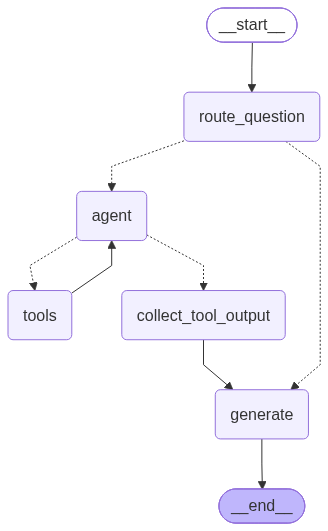

In [76]:
graph

In [77]:
# Case 1: vector store only — domain-specific question about the PDF
query_vs = "According to the report, how will the adoption of electric vehicles impact oil demand?"

result_vs = graph.invoke({"query": query_vs, "messages": [], "retrieved_docs": [], "context": ""})

In [78]:
result_vs

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 131, 'prompt_tokens': 438, 'total_tokens': 569, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EAt74EGoMhQNvPPKft6OdWCwMSt9B', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe59f-2b27-7221-8a9d-dfc64dc49937-0', tool_calls=[{'name': 'vector_store_search', 'args': {'query': 'electric vehicle adoption impact on oil demand report Will EVs Dampen the Oil Price Shock? oil demand displacement scenarios fleet turnover projections battery cost trends OPEC+ supply behavior energy price volatility through 2050', 'k': 8}, 'id': 'call_OOrZl18vi89oLYhctTpvOKtC',

In [79]:
# Case 2: web search only — current information not in the PDF
query_web = "What is the current temperature in New Delhi?"

result_web = graph.invoke({"query": query_web, "messages": [], "retrieved_docs": [], "context": ""})

In [80]:
result_web

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 98, 'prompt_tokens': 431, 'total_tokens': 529, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EAt8Q8sF5LRowUo9gkUdTfak4228u', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe5a0-75a4-74c0-89e4-730fa35f5471-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'New Delhi current temperature now weather', 'max_results': 3}, 'id': 'call_4xrkekg020XxaZNWHJHFlT8d', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 431, 'output_tokens': 98, 'total_tokens': 529, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_t

In [81]:
# Case 3: both tools — requires document context AND current web data
query_both = "Compare what the EV report projects for 2030 oil demand and also tell me about the weather in mumbai"

result_both = graph.invoke({"query": query_both, "messages": [], "retrieved_docs": [], "context": ""})

In [82]:
result_both

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 349, 'prompt_tokens': 444, 'total_tokens': 793, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 256, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EAt9HwoYfMzvsK5WtueKqHQD3Cj0d', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe5a1-42af-7c11-b4e4-385c51b82cd5-0', tool_calls=[{'name': 'vector_store_search', 'args': {'query': 'Will EVs Dampen the Oil Price Shock? 2030 oil demand projections 2030 oil demand displacement scenarios fleet turnover EV adoption trajectories', 'k': 5}, 'id': 'call_k9sqLgYMFdeFHTOj2TzwxjWk', 'type': 'tool_call'}, {'name': 'web_search', 'args': {'query': 'Mumbai current weathe

In [83]:
print(result_both['generation'])

The EV report discusses projections for oil demand displacement due to electric vehicle (EV) adoption but does not provide specific figures for oil demand in 2030. It emphasizes that complete fleet electrification cannot occur in less than two decades, suggesting that significant reductions in oil demand may not be expected until well after 2030, particularly given factors like the annual sales trajectory for new EVs, the retirement rate of existing internal combustion engine (ICE) vehicles, and their average mileage and fuel economy.

Regarding the weather in Mumbai, as of August 9, 2026, the current temperature is 28.6°C with patchy rain nearby. The humidity is at 76%, and wind is coming from the west at 15.9 mph. The weather condition indicates that it feels like 32.9°C. The forecast shows similar conditions expected over the following days, with temperatures around 29°C and a chance of rain.
